# BraTS 2020 EDA — 핵심 인사이트 5가지

> **목적**: 전처리 전략과 모델링 결정을 위한 핵심 데이터 탐색

| # | 분석 | 전처리/모델링 연결 |
|---|------|----------------|
| 1 | 데이터 구조 확인 | 파일 누락, shape, label 값 |
| 2 | 클래스 불균형 | Loss 가중치, oversample 비율 결정 |
| 3 | 종양 위치 heatmap | 빈 slice 제거 임계값 결정 |
| 4 | Modality intensity 분포 | Z-score 정규화 근거 |
| 5 | 대표 환자 시각화 | 전처리 결과 사전 검증 |


In [9]:
# Cell 1 (임포트 셀) 맨 앞에 추가
import subprocess
import sys

# koreanize_matplotlib 설치 (한 번만)
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "koreanize_matplotlib"])

import koreanize_matplotlib
import matplotlib.pyplot as plt

## 0. 임포트 및 경로 설정

In [10]:
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 11

# 경로 설정
DATA_ROOT = Path('/Users/hong-igdaebaiohelseu/brats_work/brats20-dataset-training-validation')
if not DATA_ROOT.exists():
    DATA_ROOT = Path.home() / 'Desktop' / 'brats_work' / 'brats20-dataset-training-validation'

TRAIN_DIR = DATA_ROOT / 'BraTS2020_TrainingData' / 'MICCAI_BraTS2020_TrainingData'
SAVE_DIR  = Path.home() / 'brats_work' / 'eda_outputs'
SAVE_DIR.mkdir(parents=True, exist_ok=True)

MODALITIES  = ['flair', 't1ce', 't1', 't2']
LABELS_KR   = {'flair':'FLAIR', 't1ce':'T1ce', 't1':'T1', 't2':'T2'}
patient_dirs = sorted([d for d in TRAIN_DIR.iterdir() if d.is_dir()])
print(f'환자 수: {len(patient_dirs)}')
print(f'저장 경로: {SAVE_DIR}')


환자 수: 369
저장 경로: /Users/jangyunseo/brats_work/eda_outputs


## EDA 1. 데이터 구조 확인

**목적**: 파일 누락, shape, label 고유값 확인  
**인사이트** → 전처리 파이프라인 설계 기준


In [11]:
# 파일 존재 여부 확인
missing, valid_dirs = [], []
for pdir in patient_dirs:
    pid = pdir.name
    files = {m: pdir / f'{pid}_{m}.nii' for m in MODALITIES + ['seg']}
    if all(f.exists() for f in files.values()):
        valid_dirs.append(pdir)
    else:
        missing.append(pid)

print(f'유효 환자: {len(valid_dirs)} / {len(patient_dirs)}')
if missing:
    print(f'누락: {missing}')

# 대표 환자 shape / label 확인 (3명)
print(f'\n{chr(9472)*55}')
print(f'{"환자ID":30} {"Shape":15} {"Labels"}')
print(f'{chr(9472)*55}')
for pdir in valid_dirs[:3]:
    pid = pdir.name
    img = nib.load(pdir / f'{pid}_flair.nii').get_fdata()
    seg = nib.load(pdir / f'{pid}_seg.nii').get_fdata()
    labels = sorted(np.unique(seg).astype(int).tolist())
    print(f'{pid:30} {str(img.shape):15} {labels}')

print(f'\n레이블 정의:')
print(f'  0 = Background')
print(f'  1 = Necrosis/NET  -> TC, WT')
print(f'  2 = Edema         -> WT만')
print(f'  4 = Enhancing     -> ET, TC, WT')
print(f'  (레이블 3은 존재하지 않음)')


유효 환자: 368 / 369
누락: ['BraTS20_Training_355']

───────────────────────────────────────────────────────
환자ID                           Shape           Labels
───────────────────────────────────────────────────────
BraTS20_Training_001           (240, 240, 155) [0, 1, 2, 4]
BraTS20_Training_002           (240, 240, 155) [0, 1, 2, 4]
BraTS20_Training_003           (240, 240, 155) [0, 1, 2, 4]

레이블 정의:
  0 = Background
  1 = Necrosis/NET  -> TC, WT
  2 = Edema         -> WT만
  4 = Enhancing     -> ET, TC, WT
  (레이블 3은 존재하지 않음)


## EDA 2. 클래스 불균형 분석

**목적**: WT/TC/ET의 voxel 비율 + 빈 slice 비율  
**인사이트** → Loss 가중치(WT 2.0), tumor oversample 70% 결정 근거


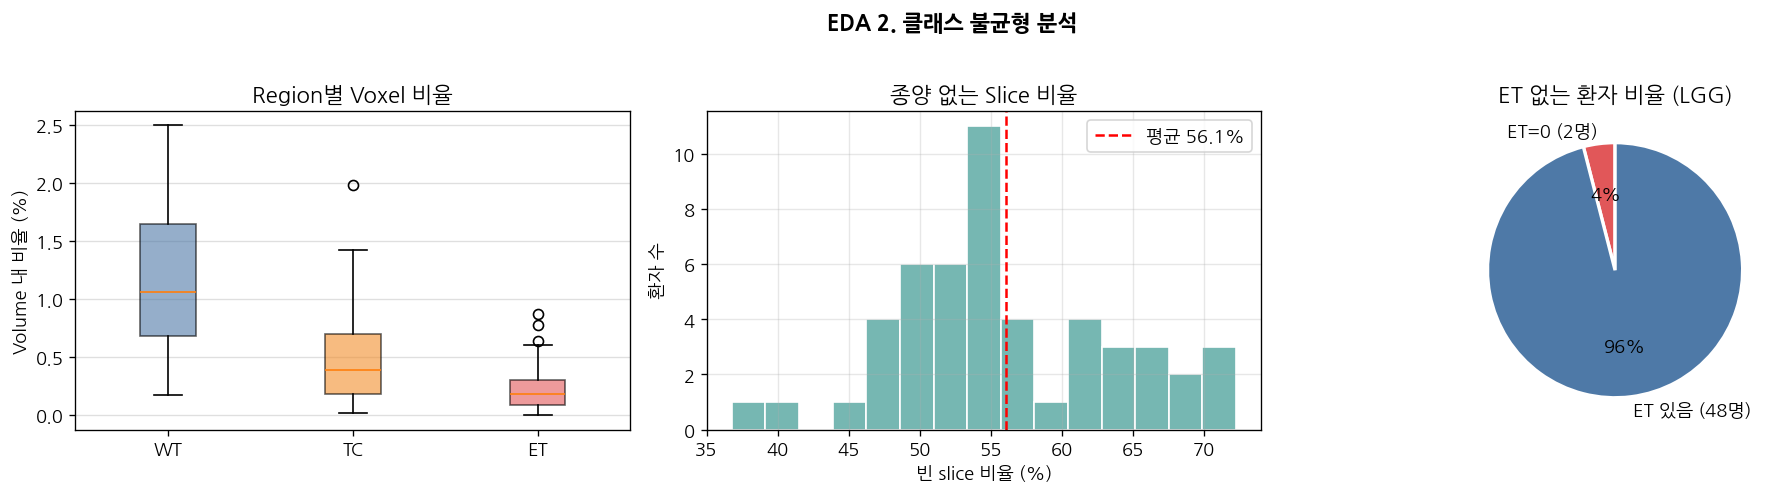

WT 평균: 1.198%
TC 평균: 0.502%
ET 평균: 0.229%
빈 slice 평균: 56.1%
ET=0 환자: 2/50 (4%)

→ Loss: WT 가중치 2.0, Tversky(beta=0.7), oversample 70%


In [12]:
SAMPLE_N = 50
np.random.seed(42)
sample_dirs = np.random.choice(valid_dirs, SAMPLE_N, replace=False)

wt_ratios, tc_ratios, et_ratios, empty_ratios = [], [], [], []
et_zero = 0

for pdir in sample_dirs:
    pid = pdir.name
    seg = nib.load(pdir / f'{pid}_seg.nii').get_fdata()
    total = seg.size
    wt = ((seg==1)|(seg==2)|(seg==4)).sum()
    tc = ((seg==1)|(seg==4)).sum()
    et = (seg==4).sum()
    wt_ratios.append(wt/total*100)
    tc_ratios.append(tc/total*100)
    et_ratios.append(et/total*100)
    empty = sum(1 for z in range(seg.shape[2]) if seg[:,:,z].sum()==0)
    empty_ratios.append(empty/seg.shape[2]*100)
    if et == 0: et_zero += 1

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
colors = ['#4e79a7','#f28e2b','#e15759']

# Boxplot
bp = axes[0].boxplot([wt_ratios, tc_ratios, et_ratios],
                     labels=['WT','TC','ET'], patch_artist=True)
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c); patch.set_alpha(0.6)
axes[0].set_ylabel('Volume 내 비율 (%)')
axes[0].set_title('Region별 Voxel 비율')
axes[0].grid(axis='y', alpha=0.4)

# 빈 slice histogram
axes[1].hist(empty_ratios, bins=15, color='#76b7b2', edgecolor='white')
axes[1].axvline(np.mean(empty_ratios), color='red', ls='--',
                label=f'평균 {np.mean(empty_ratios):.1f}%')
axes[1].set_xlabel('빈 slice 비율 (%)')
axes[1].set_ylabel('환자 수')
axes[1].set_title('종양 없는 Slice 비율')
axes[1].legend(); axes[1].grid(alpha=0.3)

# ET=0 pie
axes[2].pie([et_zero, SAMPLE_N-et_zero],
            labels=[f'ET=0 ({et_zero}명)', f'ET 있음 ({SAMPLE_N-et_zero}명)'],
            colors=['#e15759','#4e79a7'], autopct='%1.0f%%',
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[2].set_title('ET 없는 환자 비율 (LGG)')

plt.suptitle('EDA 2. 클래스 불균형 분석', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(SAVE_DIR / 'eda2_class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'WT 평균: {np.mean(wt_ratios):.3f}%')
print(f'TC 평균: {np.mean(tc_ratios):.3f}%')
print(f'ET 평균: {np.mean(et_ratios):.3f}%')
print(f'빈 slice 평균: {np.mean(empty_ratios):.1f}%')
print(f'ET=0 환자: {et_zero}/{SAMPLE_N} ({et_zero/SAMPLE_N*100:.0f}%)')
print(f'\n→ Loss: WT 가중치 2.0, Tversky(beta=0.7), oversample 70%')


## EDA 3. 종양 위치 Heatmap

**목적**: 종양이 어느 z축에 집중되는가  
**인사이트** → 빈 slice 제거 임계값, adjacent slice 설계 근거


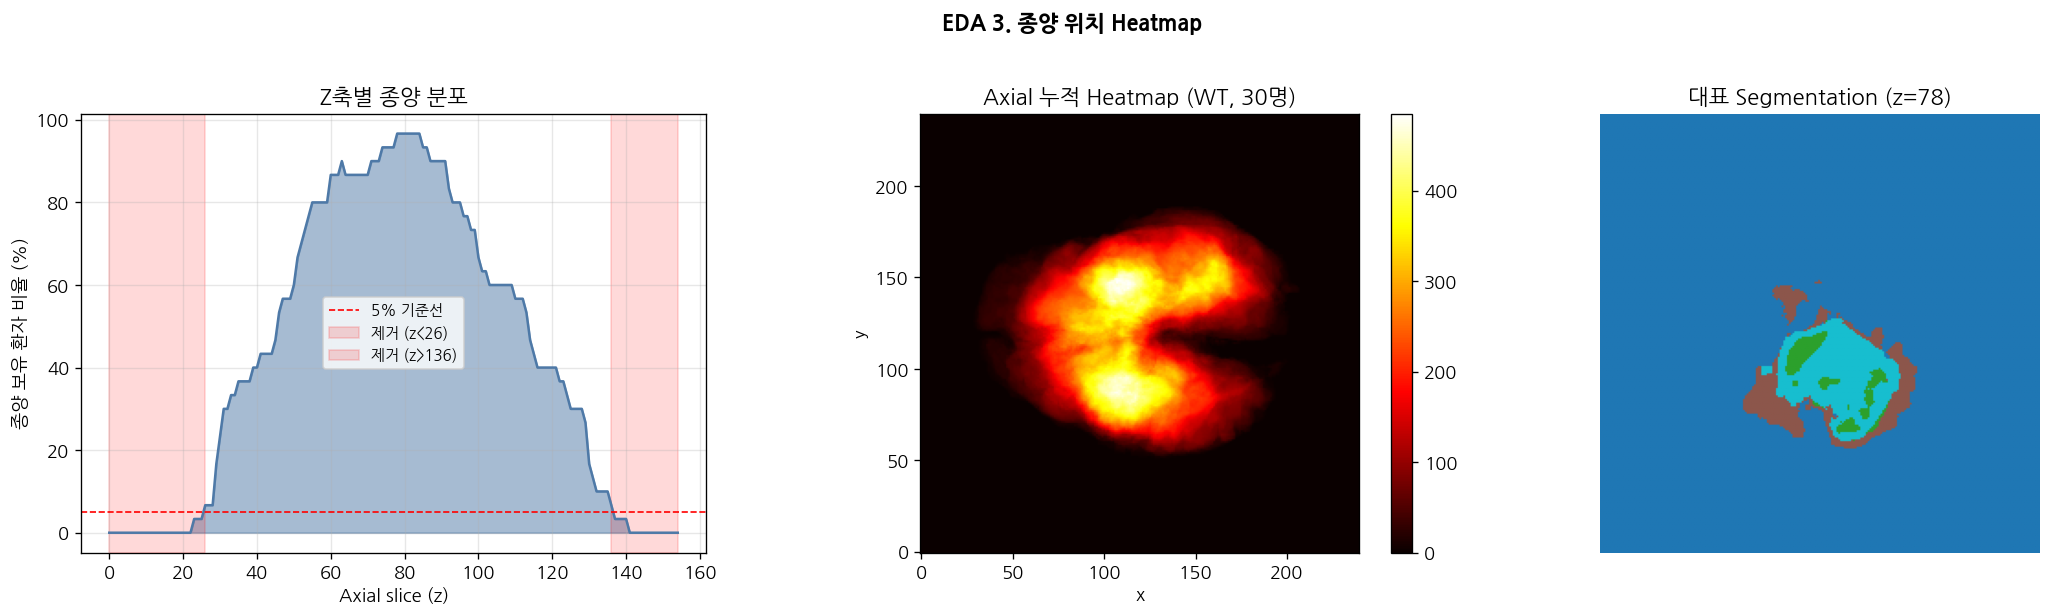

유효 z축 범위: 26 ~ 136
-> BRAIN_THR=500 으로 자동 처리 가능


In [13]:
HEATMAP_N = 30
hm_dirs = np.random.choice(valid_dirs, HEATMAP_N, replace=False)

z_count  = np.zeros(155)
heat_wt  = np.zeros((240, 240))

for pdir in hm_dirs:
    pid = pdir.name
    seg = nib.load(pdir / f'{pid}_seg.nii').get_fdata()
    d   = min(seg.shape[2], 155)
    for z in range(d):
        if seg[:,:,z].sum() > 0:
            z_count[z] += 1
    wt = ((seg==1)|(seg==2)|(seg==4)).sum(axis=2)
    h, w = wt.shape
    heat_wt[:h, :w] += wt

z_ratio = z_count / HEATMAP_N * 100
low_z   = int(np.where(z_ratio > 5)[0][0])  if (z_ratio > 5).any() else 0
high_z  = int(np.where(z_ratio > 5)[0][-1]) if (z_ratio > 5).any() else 154

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# z축별 종양 비율
axes[0].fill_between(range(155), z_ratio, alpha=0.5, color='#4e79a7')
axes[0].plot(range(155), z_ratio, color='#4e79a7', lw=1.5)
axes[0].axhline(5, color='red', ls='--', lw=1, label='5% 기준선')
axes[0].axvspan(0, low_z, alpha=0.15, color='red', label=f'제거 (z<{low_z})')
axes[0].axvspan(high_z, 154, alpha=0.15, color='red', label=f'제거 (z>{high_z})')
axes[0].set_xlabel('Axial slice (z)')
axes[0].set_ylabel('종양 보유 환자 비율 (%)')
axes[0].set_title('Z축별 종양 분포')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

# 누적 heatmap
im = axes[1].imshow(heat_wt, cmap='hot', origin='lower')
plt.colorbar(im, ax=axes[1], fraction=0.046)
axes[1].set_title(f'Axial 누적 Heatmap (WT, {HEATMAP_N}명)')
axes[1].set_xlabel('x'); axes[1].set_ylabel('y')

# 가장 많은 z에서 대표 segmentation
peak_z = int(np.argmax(z_ratio))
pdir   = hm_dirs[0]; pid = pdir.name
seg_ex = nib.load(pdir / f'{pid}_seg.nii').get_fdata()
axes[2].imshow(seg_ex[:,:,peak_z].T, cmap='tab10', origin='lower', vmin=0, vmax=4)
axes[2].set_title(f'대표 Segmentation (z={peak_z})')
axes[2].axis('off')

plt.suptitle('EDA 3. 종양 위치 Heatmap', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(SAVE_DIR / 'eda3_tumor_location.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'유효 z축 범위: {low_z} ~ {high_z}')
print(f'-> BRAIN_THR=500 으로 자동 처리 가능')


## EDA 4. Modality별 Intensity 분포

**목적**: 환자간 intensity 편차, 종양-배경 contrast 확인  
**인사이트** → Z-score 정규화 필수, T1ce가 ET 검출에 유리


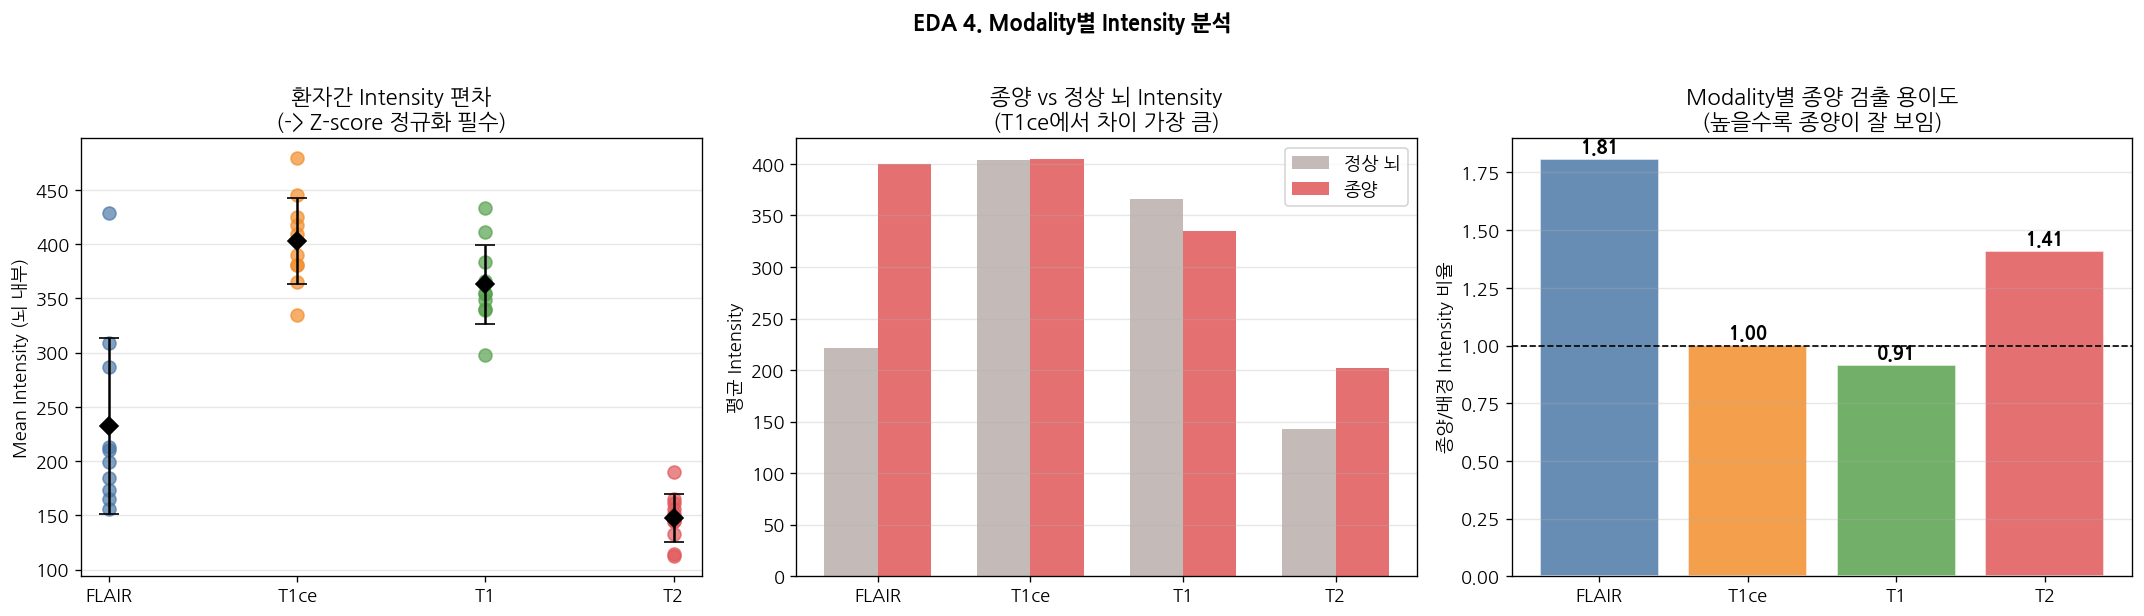

-> Z-score 정규화: 뇌 내부(>0) 기준, modality별 독립
-> Modality 순서: [flair, t1ce, t1, t2] (T1ce 우선)


In [14]:
INTENSITY_N  = 10
int_dirs = valid_dirs[:INTENSITY_N]
mod_stats = {m: {'means':[], 'tumor_mean':[], 'bg_mean':[]} for m in MODALITIES}

for pdir in int_dirs:
    pid = pdir.name
    seg = nib.load(pdir / f'{pid}_seg.nii').get_fdata()
    tumor_mask = (seg > 0)
    for m in MODALITIES:
        vol = nib.load(pdir / f'{pid}_{m}.nii').get_fdata()
        brain = vol[vol > 0]
        mod_stats[m]['means'].append(brain.mean())
        if tumor_mask.sum() > 0:
            mod_stats[m]['tumor_mean'].append(vol[tumor_mask].mean())
            mod_stats[m]['bg_mean'].append(vol[~tumor_mask & (vol>0)].mean())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['#4e79a7','#f28e2b','#59a14f','#e15759']

# 환자간 mean 편차
for i, m in enumerate(MODALITIES):
    axes[0].scatter([i+1]*INTENSITY_N, mod_stats[m]['means'],
                    color=colors[i], alpha=0.7, s=60, zorder=3)
    axes[0].errorbar(i+1, np.mean(mod_stats[m]['means']),
                     yerr=np.std(mod_stats[m]['means']),
                     fmt='D', color='black', capsize=6, ms=8, zorder=4)
axes[0].set_xticks([1,2,3,4])
axes[0].set_xticklabels([LABELS_KR[m] for m in MODALITIES])
axes[0].set_ylabel('Mean Intensity (뇌 내부)')
axes[0].set_title('환자간 Intensity 편차\n(-> Z-score 정규화 필수)')
axes[0].grid(axis='y', alpha=0.3)

# 종양 vs 배경
x = np.arange(len(MODALITIES)); w = 0.35
t_means = [np.mean(mod_stats[m]['tumor_mean']) for m in MODALITIES]
b_means = [np.mean(mod_stats[m]['bg_mean'])    for m in MODALITIES]
axes[1].bar(x-w/2, b_means, w, label='정상 뇌', color='#bab0ac', alpha=0.85)
axes[1].bar(x+w/2, t_means, w, label='종양',    color='#e15759', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels([LABELS_KR[m] for m in MODALITIES])
axes[1].set_ylabel('평균 Intensity')
axes[1].set_title('종양 vs 정상 뇌 Intensity\n(T1ce에서 차이 가장 큼)')
axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)

# contrast ratio
ratios = [t/b for t,b in zip(t_means, b_means)]
bars = axes[2].bar([LABELS_KR[m] for m in MODALITIES], ratios,
                   color=colors, alpha=0.85, edgecolor='white')
axes[2].axhline(1.0, color='black', ls='--', lw=1)
axes[2].set_ylabel('종양/배경 Intensity 비율')
axes[2].set_title('Modality별 종양 검출 용이도\n(높을수록 종양이 잘 보임)')
axes[2].grid(axis='y', alpha=0.3)
for bar, r in zip(bars, ratios):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f'{r:.2f}', ha='center', va='bottom', fontweight='bold')

plt.suptitle('EDA 4. Modality별 Intensity 분석', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(SAVE_DIR / 'eda4_modality_intensity.png', dpi=150, bbox_inches='tight')
plt.show()

print('-> Z-score 정규화: 뇌 내부(>0) 기준, modality별 독립')
print('-> Modality 순서: [flair, t1ce, t1, t2] (T1ce 우선)')


## EDA 5. 대표 환자 시각화

**목적**: 4 modality + segmentation mask overlay  
**인사이트** → 전처리 전 원본 데이터 상태 직접 확인


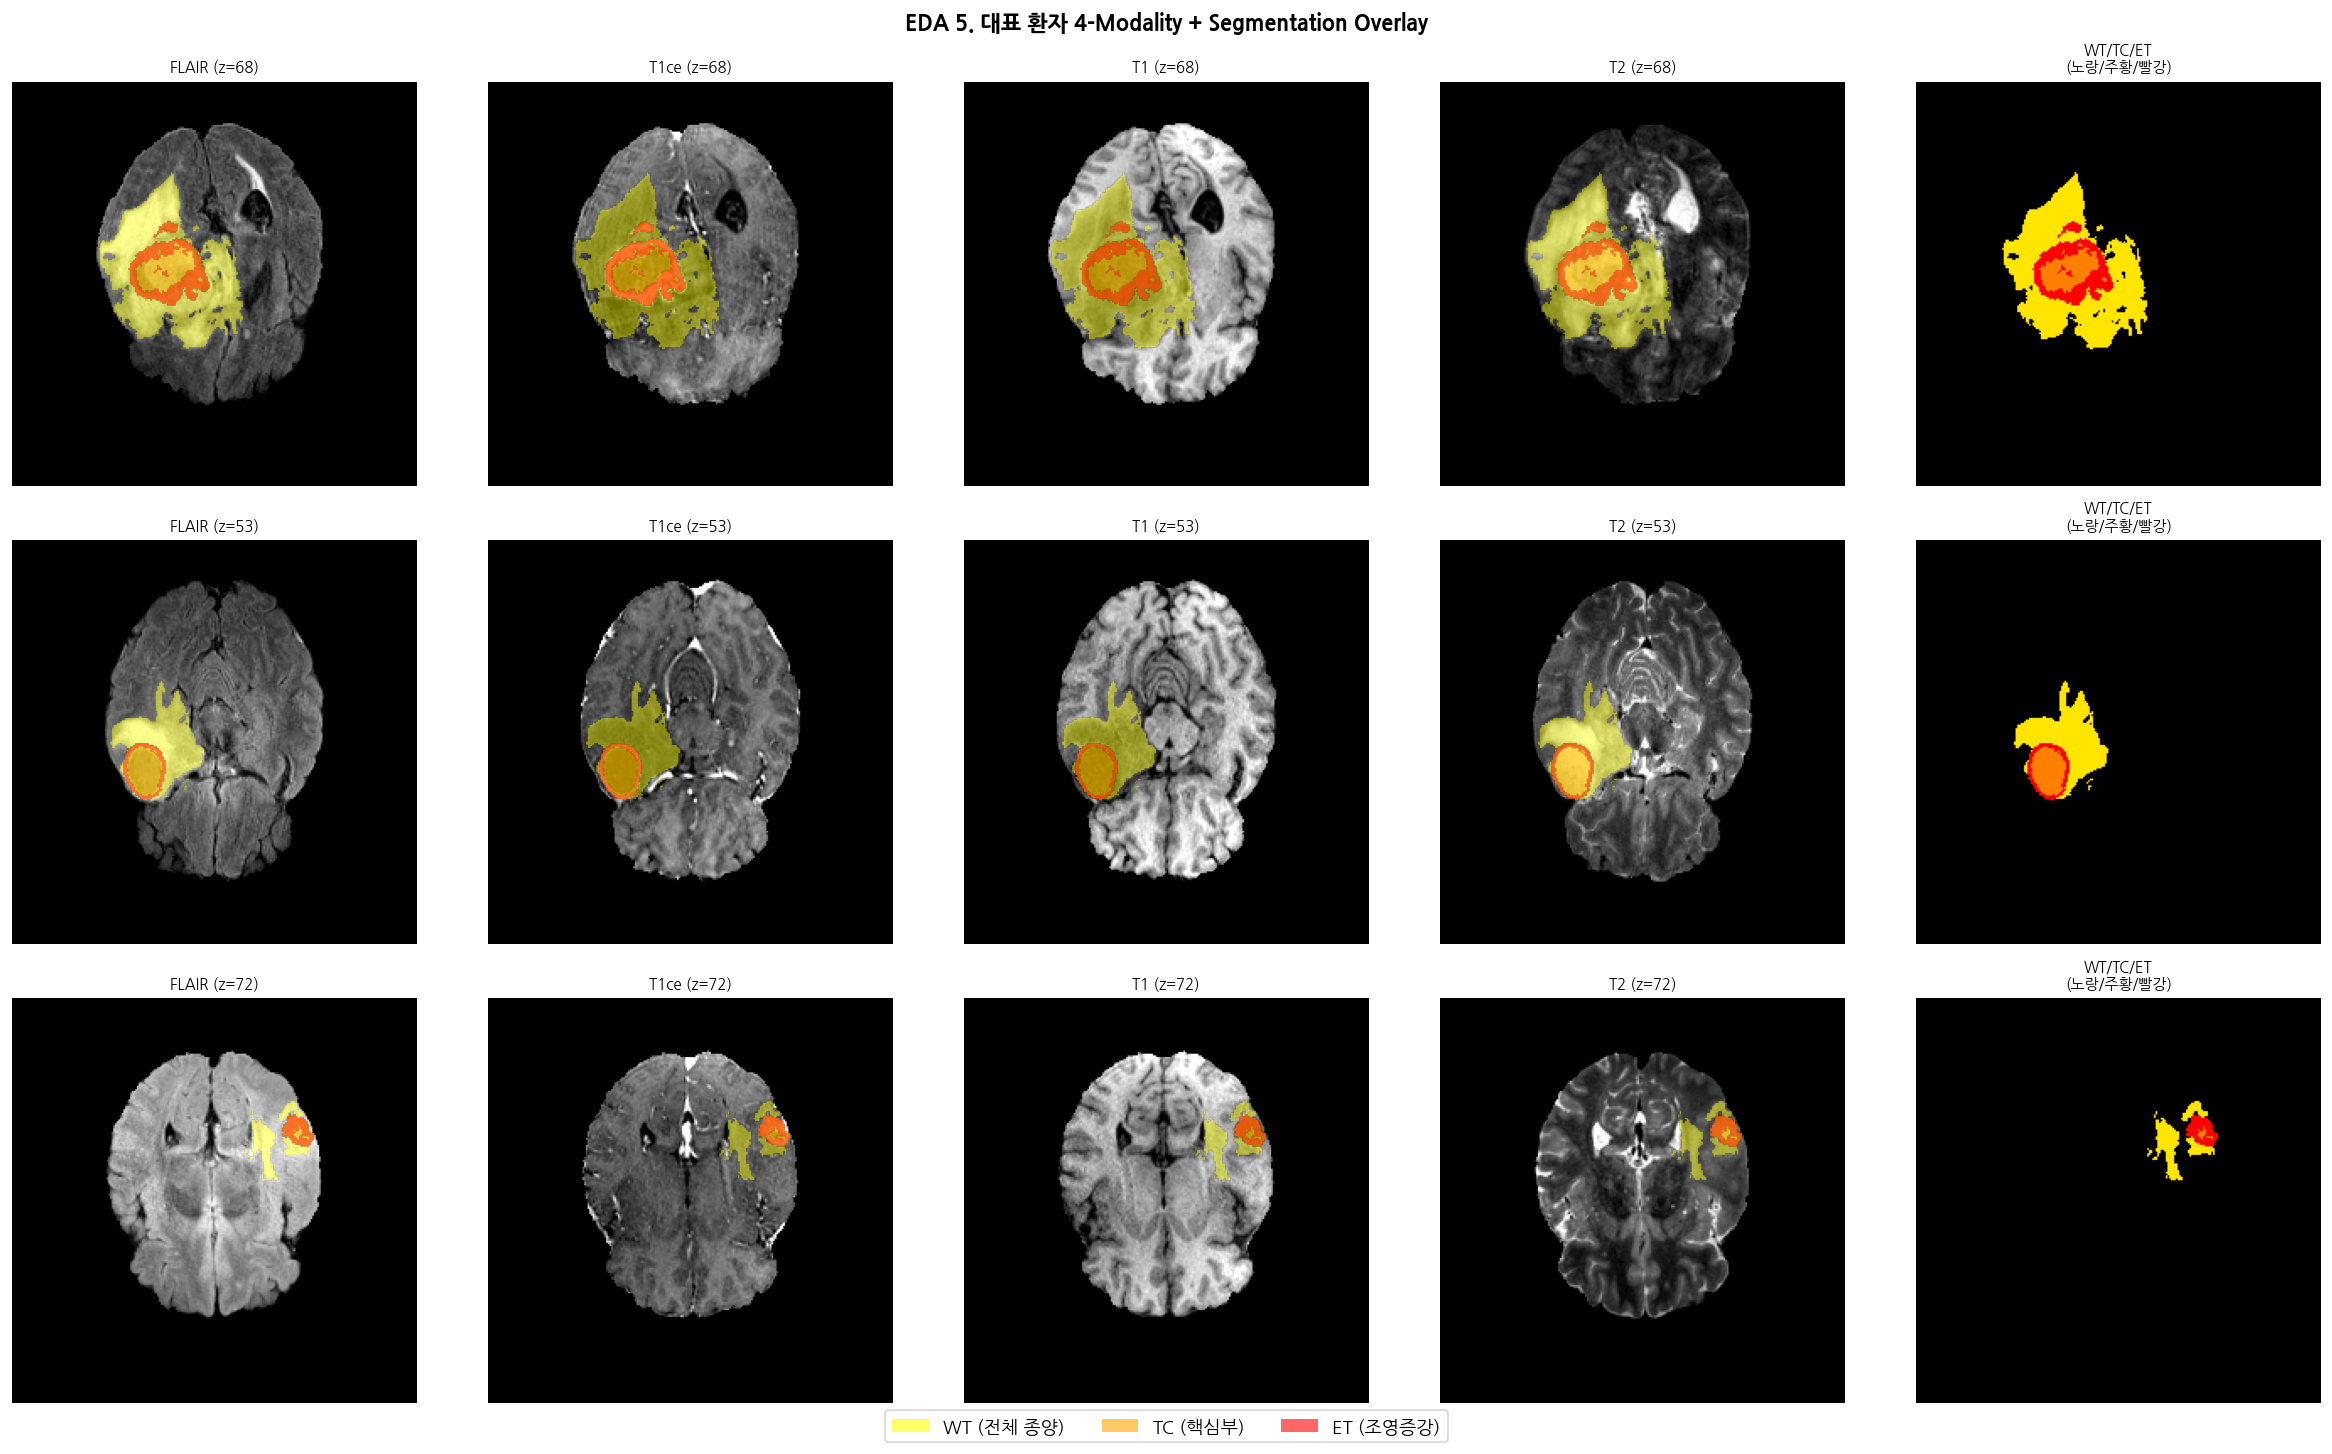

In [15]:
def overlay_mask(ax, img, seg_slice, title):
    vmin, vmax = np.percentile(img[img>0], [1,99]) if img.max()>0 else (0,1)
    ax.imshow(img.T, cmap='gray', origin='lower', vmin=vmin, vmax=vmax)
    for mask, color in [
        (((seg_slice==1)|(seg_slice==2)|(seg_slice==4)), 'yellow'),
        (((seg_slice==1)|(seg_slice==4)), 'orange'),
        ((seg_slice==4), 'red')
    ]:
        if mask.sum() > 0:
            rgba = np.zeros((*mask.T.shape, 4))
            c = mcolors.to_rgba(color)
            rgba[mask.T] = (*c[:3], 0.45)
            ax.imshow(rgba, origin='lower')
    ax.set_title(title, fontsize=9); ax.axis('off')

SHOW_N   = 3
show_dirs = valid_dirs[:SHOW_N]
fig, axes = plt.subplots(SHOW_N, 5, figsize=(20, 4*SHOW_N))

for row, pdir in enumerate(show_dirs):
    pid = pdir.name
    seg = nib.load(pdir / f'{pid}_seg.nii').get_fdata()
    z_best = int(np.argmax([seg[:,:,z].sum() for z in range(seg.shape[2])]))

    for ci, m in enumerate(MODALITIES):
        vol = nib.load(pdir / f'{pid}_{m}.nii').get_fdata()
        overlay_mask(axes[row, ci], vol[:,:,z_best], seg[:,:,z_best],
                     f'{LABELS_KR[m]} (z={z_best})')

    # Region 분리
    seg_z = seg[:,:,z_best]
    rgb = np.zeros((*seg_z.shape, 3))
    rgb[(seg_z==1)|(seg_z==2)|(seg_z==4)] = [1.0, 0.9, 0.0]  # WT
    rgb[(seg_z==1)|(seg_z==4)]             = [1.0, 0.5, 0.0]  # TC
    rgb[seg_z==4]                          = [1.0, 0.0, 0.0]  # ET
    axes[row, 4].imshow(rgb.transpose(1,0,2), origin='lower')
    axes[row, 4].set_title('WT/TC/ET\n(노랑/주황/빨강)', fontsize=9)
    axes[row, 4].axis('off')

from matplotlib.patches import Patch
legend = [Patch(facecolor='yellow', alpha=0.6, label='WT (전체 종양)'),
          Patch(facecolor='orange', alpha=0.6, label='TC (핵심부)'),
          Patch(facecolor='red',    alpha=0.6, label='ET (조영증강)')]
fig.legend(handles=legend, loc='lower center', ncol=3, fontsize=11,
           bbox_to_anchor=(0.5, -0.02))

plt.suptitle('EDA 5. 대표 환자 4-Modality + Segmentation Overlay',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR / 'eda5_visualization.png', dpi=150, bbox_inches='tight')
plt.show()


## 종합 인사이트 → 전처리 & 모델링 결정사항

| EDA | 발견 | 결정 |
|-----|------|------|
| **1. 구조** | shape (240,240,155), label {0,1,2,4} | label 3 없음 주의 |
| **2. 불균형** | ET<1%, 빈 slice ~57%, ET=0 환자 존재 | Loss: WT 가중치 2.0, Tversky β=0.7, oversample 70% |
| **3. 위치** | z=20~140에 종양 집중 | BRAIN_THR=500 으로 빈 slice 제거 |
| **4. Modality** | T1ce contrast 최대, 환자간 편차 큼 | Z-score 정규화, 순서 [flair, t1ce, t1, t2] |
| **5. 시각화** | ET가 TC 안에 포함, 매우 작음 | adjacent 5 slice (2.5D) 로 맥락 확보 |


In [16]:
print('=' * 60)
print('EDA 완료 — 전처리/모델링 결정사항')
print('=' * 60)
decisions = [
    ('정규화',     'Z-score (뇌 내부 voxel 기준, modality별 독립)'),
    ('Crop',      'Brain bounding box crop (margin=5)'),
    ('Resize',    '192 x 192 (HW축)'),
    ('빈 slice',  'BRAIN_THR=500 (뇌 voxel < 500 이면 제거)'),
    ('Oversample','tumor slice 70% 이상'),
    ('Loss',      'Tversky (alpha=0.3, beta=0.7)'),
    ('가중치',    'WT=2.0, TC=1.0, ET=1.0'),
    ('입력',      '2.5D adjacent 5 slices x 4 modality = 20 채널'),
]
for k, v in decisions:
    print(f'  {k:12}: {v}')
print(f'\nEDA 이미지 저장: {SAVE_DIR}')


EDA 완료 — 전처리/모델링 결정사항
  정규화         : Z-score (뇌 내부 voxel 기준, modality별 독립)
  Crop        : Brain bounding box crop (margin=5)
  Resize      : 192 x 192 (HW축)
  빈 slice     : BRAIN_THR=500 (뇌 voxel < 500 이면 제거)
  Oversample  : tumor slice 70% 이상
  Loss        : Tversky (alpha=0.3, beta=0.7)
  가중치         : WT=2.0, TC=1.0, ET=1.0
  입력          : 2.5D adjacent 5 slices x 4 modality = 20 채널

EDA 이미지 저장: /Users/jangyunseo/brats_work/eda_outputs
